In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Part 1 : Trapezoidal Rule

In [2]:
def integrate_trapezoid(func, a, b, n):
    h = (b-a)/n
    s = (func(a)+func(b))/2

    for i in range(1,n):
        x = a + i*h
        s += func(x)

    return h*s

In [ ]:
def integrate_trapezoid(func, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = func(x)
    h = (b - a) / n
    
    return (h/2) * (y[0] + 2*np.sum(y[1:-1]) + y[-1])

In [8]:
def f(x):
    return np.cos(x)

a = 0
b = np.pi / 2
exact = 1

N_values = [10**i for i in range(1, 9)]
errors = []

for n in N_values:
    approx = integrate_trapezoid(f, a, b, n)
    error = abs(exact - approx)
    errors.append(error)


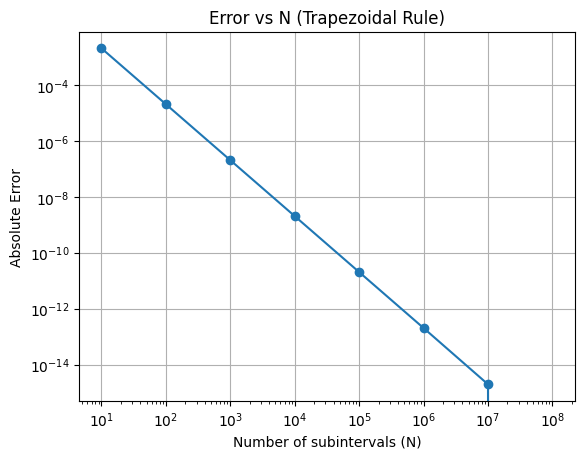

In [9]:
plt.figure()
plt.loglog(N_values, errors, marker='o')
plt.xlabel("Number of subintervals (N)")
plt.ylabel("Absolute Error")
plt.title("Error vs N (Trapezoidal Rule)")
plt.grid()

plt.show()

## Part 2: Simpson's Rule

In [13]:
def integrate_simpson(func, a, b, n):
    if n % 2 != 0:
        print("n must be even for Simpson's Rule")
    
    x = np.linspace(a, b, n + 1)
    y = func(x)
    h = (b - a) / n
    
    return (h/3) * ( y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1] )

In [14]:
N_values = [10**i for i in range(1, 9)]
errors = []

for n in N_values:
    approx = integrate_simpson(f, a, b, n)
    error = abs(exact - approx)
    errors.append(error)

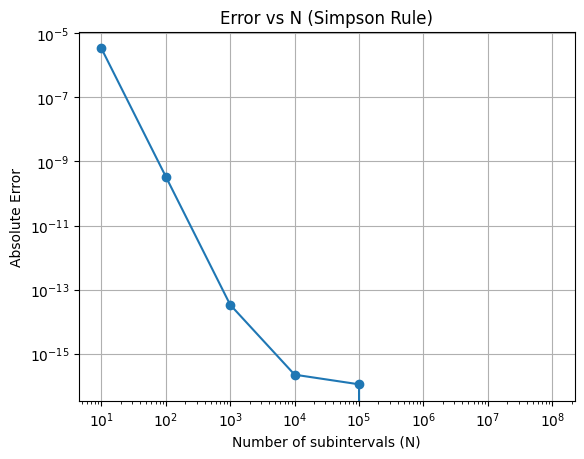

In [15]:
plt.figure()
plt.loglog(N_values, errors, marker='o')
plt.xlabel("Number of subintervals (N)")
plt.ylabel("Absolute Error")
plt.title("Error vs N (Simpson Rule)")
plt.grid()

plt.show()

### Part 3: Gauss-Legendre Quadrature

In [16]:
def gauss_legendre_quadrature(func, a, b, n):
    xi, wi = np.polynomial.legendre.leggauss(n)
    x = 0.5 * (b - a) * xi + 0.5 * (b + a)

    return 0.5 * (b - a) * np.sum(wi * func(x))

In [17]:
a = -1
b = 1

N_values = [2, 4, 8, 10]
for n in N_values:
    approx = gauss_legendre_quadrature(f, a, b, n)
    print(f"for {n}, approx integral is : ", approx)

for 2, approx integral is :  1.6758236553899863
for 4, approx integral is :  1.6829416886959736
for 8, approx integral is :  1.6829419696157926
for 10, approx integral is :  1.6829419696157926
